# Stationary Period Analysis with YOLO - Step by Step

Notebook นี้แบ่งการทำงานเป็นขั้น ๆ เพื่อให้ดูผลระหว่างทางได้ เช่น:

- โหลดวิดีโอและดูข้อมูลพื้นฐาน
- แสดง frame ตัวอย่าง
- ใช้ YOLO ตี bounding box คนใน frame เดียว
- ใช้ YOLO tracking เพื่อดู `track_id` ของคนเดิม
- สร้างวิดีโอ annotated แบบ slow-motion
- คำนวณ stationary period เป็นวินาที
- วาดกราฟว่าแต่ละ ID เคลื่อนที่หรืออยู่นิ่งช่วงไหน

Method หลักที่ใช้วัด stationary duration คือ:

`YOLO person detection + ByteTrack tracking ID + frame-to-frame center displacement + movement threshold`

## 1. Install Dependencies

ถ้ายังไม่ได้ติดตั้ง package ให้รัน cell นี้ก่อน 1 ครั้ง

ถ้าติดตั้งแล้ว สามารถข้าม cell นี้ได้

In [ ]:
# ถ้ายังไม่ได้ติดตั้ง ให้เอาเครื่องหมาย # ด้านหน้าออก แล้วรัน cell นี้
# !pip install ultralytics opencv-python matplotlib pandas numpy

## 2. Import Libraries

ส่วนนี้โหลด library ที่จำเป็นสำหรับงานวิดีโอ, YOLO, ตารางข้อมูล และกราฟ

In [ ]:
from pathlib import Path
import math
import cv2
import numpy as np

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Video, display
from ultralytics import YOLO

plt.rcParams["figure.figsize"] = (12, 6)

## 3. ตั้งค่าไฟล์และ Parameter

ค่าที่ปรับบ่อย:

- `VIDEO_PATH`: path วิดีโอ input
- `MODEL_PATH`: model YOLO
- `CONFIDENCE`: ความมั่นใจขั้นต่ำของ detection
- `TRACKING_AUDIT_TRACKER`: tracker สำหรับเช็ก ID ทั้งคลิป (`botsort.yaml` หรือ `bytetrack.yaml`)
- `TRACKING_AUDIT_SLOW_FACTOR`: ทำวิดีโอ audit ให้ช้าลงเพื่อดู ID ช่วงโดนบัง/เดินผ่านกันง่ายขึ้น
- `STATIONARY_SPEED_THRESHOLD`: ถ้า speed ต่ำกว่าค่านี้ ถือว่าอยู่นิ่ง
- `SLOW_FACTOR`: ทำ output video ของ stationary analysis ให้ช้าลง
- `MAX_FRAMES_FOR_TEST`: ใช้ `None` เพื่อรันทั้งคลิป หรือใส่ตัวเลขเพื่อทดสอบบางช่วง


In [ ]:
PROJECT_DIR = Path.cwd()

def find_existing_path(candidate_paths):
    """เลือก path แรกที่มีอยู่จริง เพื่อให้ notebook ใช้ได้จากหลาย working directory"""
    for candidate_path in candidate_paths:
        candidate_path = Path(candidate_path)
        if candidate_path.exists():
            return candidate_path
    return Path(candidate_paths[0])


# รองรับทั้งกรณีเปิด notebook จาก folder หลัก และจาก folder stationary_analysis
VIDEO_PATH = find_existing_path(["stationary_analysis/entrance.mov", "entrance.mov"])
MODEL_PATH = find_existing_path(["stationary_analysis/yolov8n.pt", "yolov26n.pt"])

if PROJECT_DIR.name == "stationary_analysis":
    OUTPUT_DIR = Path("outputs_notebook")
else:
    OUTPUT_DIR = Path("stationary_analysis/outputs_notebook")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# YOLO COCO class id 0 = person
PERSON_CLASS_ID = 0

CONFIDENCE = 0.35
STATIONARY_SPEED_THRESHOLD = 100.0  # pixels/second
MIN_STATIONARY_SECONDS = 0.5
MAX_LOST_SECONDS = 0.5
SLOW_FACTOR = 1.0
TRACKING_AUDIT_TRACKER = "botsort.yaml"  # ถ้า ID สลับง่าย ให้ลอง "bytetrack.yaml" เปรียบเทียบ
TRACKING_AUDIT_SLOW_FACTOR = 1.0  # เพิ่มเป็น 2 หรือ 3 ถ้าอยากดู ID ช้าลง

# ใช้ None เพื่อประมวลผลทั้งคลิป
# ถ้าอยากทดสอบเร็ว ๆ ชั่วคราว ค่อยเปลี่ยนเป็น 150 หรือ 300
MAX_FRAMES_FOR_TEST = None

print("Video:", VIDEO_PATH.resolve())
print("Model:", MODEL_PATH.resolve())
print("Output folder:", OUTPUT_DIR.resolve())

Video: /Users/moi/PROJECT/err/stationary_analysis/entrance.mov
Model: /Users/moi/PROJECT/err/stationary_analysis/stationary_analysis/yolov8n.pt
Output folder: /Users/moi/PROJECT/err/stationary_analysis/outputs_notebook


## 4. โหลดวิดีโอและดูข้อมูลพื้นฐาน

เราจะดู FPS, จำนวน frame, ความกว้าง/สูง และ duration ของวิดีโอก่อน

In [ ]:
video_capture = cv2.VideoCapture(str(VIDEO_PATH))

if not video_capture.isOpened():
    raise FileNotFoundError(f"Cannot open video: {VIDEO_PATH}")

fps = video_capture.get(cv2.CAP_PROP_FPS)
frame_width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
frame_height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
duration_seconds = total_frames / fps

video_capture.release()

print(f"FPS: {fps:.2f}")
print(f"Frame size: {frame_width} x {frame_height}")
print(f"Total frames: {total_frames}")
print(f"Duration: {duration_seconds:.2f} seconds")

FPS: 29.88
Frame size: 1920 x 1080
Total frames: 2556
Duration: 85.53 seconds


## 5. แสดง Frame ตัวอย่าง

ลองดู frame แรก ๆ ก่อน เพื่อเช็กว่าอ่านวิดีโอถูกไฟล์และมุมกล้องถูกต้อง

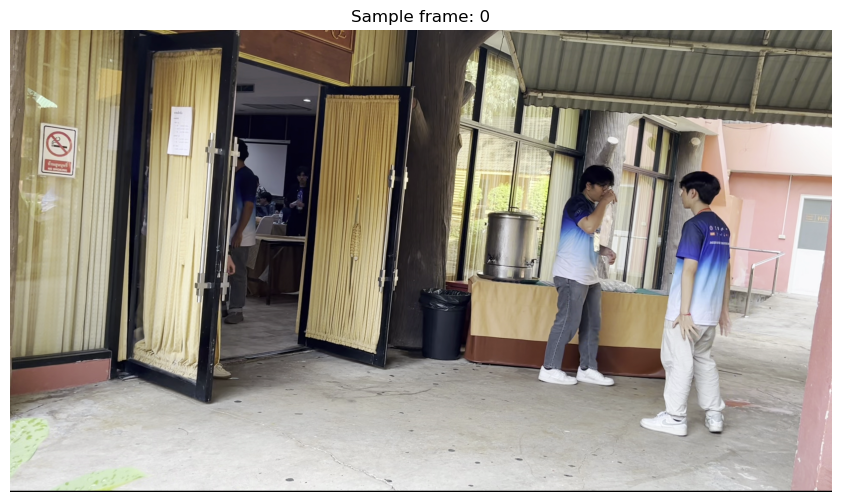

In [ ]:
def read_frame(video_path, frame_index):
    """อ่าน frame ตาม index ที่ต้องการจากวิดีโอ"""
    cap = cv2.VideoCapture(str(video_path))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)
    success, frame_bgr = cap.read()
    cap.release()

    if not success:
        raise RuntimeError(f"Cannot read frame {frame_index}")

    # OpenCV อ่านภาพเป็น BGR แต่ matplotlib ต้องการ RGB
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
    return frame_bgr, frame_rgb


SAMPLE_FRAME_INDEX = 0
sample_frame_bgr, sample_frame_rgb = read_frame(VIDEO_PATH, SAMPLE_FRAME_INDEX)

plt.imshow(sample_frame_rgb)
plt.title(f"Sample frame: {SAMPLE_FRAME_INDEX}")
plt.axis("off")
plt.show()

## 6. โหลด YOLO Model

`yolov8n.pt` เป็นรุ่นเล็ก ทำงานเร็ว เหมาะกับการทดลอง ถ้าต้องการแม่นขึ้นอาจใช้ `yolov8s.pt` หรือรุ่นใหญ่ขึ้น

In [ ]:
model = YOLO(str(MODEL_PATH))
print("YOLO model loaded")

YOLO model loaded


## 7. ทดลอง Detect คนใน Frame เดียว

Cell นี้ยังไม่ใช้ tracking ID แค่ดูว่า YOLO ตี bounding box คนได้ดีไหม

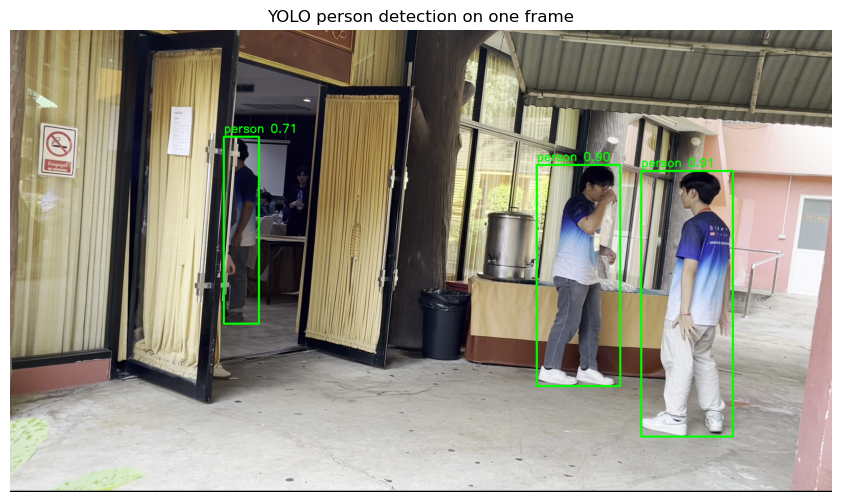

In [ ]:
detection_results = model.predict(
    sample_frame_bgr,
    classes=[PERSON_CLASS_ID],
    conf=CONFIDENCE,
    verbose=False,
)

detected_frame = sample_frame_bgr.copy()

if detection_results[0].boxes is not None:
    boxes = detection_results[0].boxes.xyxy.cpu().numpy()
    confidences = detection_results[0].boxes.conf.cpu().numpy()

    for box, confidence in zip(boxes, confidences):
        x1, y1, x2, y2 = box.astype(int)
        cv2.rectangle(detected_frame, (x1, y1), (x2, y2), (0, 255, 0), 3)
        cv2.putText(
            detected_frame,
            f"person {confidence:.2f}",
            (x1, max(30, y1 - 10)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.9,
            (0, 255, 0),
            2,
        )

detected_frame_rgb = cv2.cvtColor(detected_frame, cv2.COLOR_BGR2RGB)
plt.imshow(detected_frame_rgb)
plt.title("YOLO person detection on one frame")
plt.axis("off")
plt.show()

## 8. Helper Functions สำหรับ Tracking และ Stationary

ส่วนนี้รวม function ย่อย เพื่อให้ cell หลักอ่านง่ายขึ้น

In [ ]:
def calculate_center(box_xyxy):
    """แปลง bounding box [x1, y1, x2, y2] เป็นจุดกลาง (center_x, center_y)"""
    x1, y1, x2, y2 = box_xyxy
    center_x = (x1 + x2) / 2
    center_y = (y1 + y2) / 2
    return center_x, center_y


def calculate_speed(old_x, old_y, new_x, new_y, time_difference):
    """คำนวณ speed จากตำแหน่งเก่าและใหม่ หน่วยเป็น pixels/second"""
    if time_difference <= 0:
        return 0.0

    distance_pixels = math.hypot(new_x - old_x, new_y - old_y)
    speed_pixels_per_second = distance_pixels / time_difference
    return speed_pixels_per_second


def draw_text_box(frame, x, y, text, color):
    """วาดกล่องข้อความให้ดูง่ายบนภาพ"""
    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.65
    thickness = 2
    text_size, _ = cv2.getTextSize(text, font, font_scale, thickness)
    text_width, text_height = text_size

    y = max(text_height + 8, y)
    cv2.rectangle(frame, (x, y - text_height - 8), (x + text_width + 8, y), color, -1)
    cv2.putText(frame, text, (x + 4, y - 5), font, font_scale, (255, 255, 255), thickness)


def make_even_number(value):
    """ทำให้ width/height เป็นเลขคู่ เพื่อให้ MP4 encoder ทำงานได้ง่ายขึ้น"""
    return value if value % 2 == 0 else value - 1


def close_stationary_period(track_id, track_state, end_time, stationary_periods):
    """ปิดช่วง stationary ถ้าช่วงนั้นยาวพอ"""
    start_time = track_state.get("stationary_start_time")
    if start_time is None:
        return

    duration = end_time - start_time
    if duration >= MIN_STATIONARY_SECONDS:
        stationary_periods.append(
            {
                "track_id": track_id,
                "start_time_sec": start_time,
                "end_time_sec": end_time,
                "duration_sec": duration,
            }
        )

    track_state["stationary_start_time"] = None

## 9. Tracking เต็มวิดีโอสำหรับตรวจ ID

Cell นี้สร้างวิดีโอเต็มคลิปที่โชว์ bounding box + `track_id` ทุก frame เพื่อ audit ว่าคนเดิมยังเป็น ID เดิมไหม โดยเฉพาะช่วงที่โดนบัง เดินผ่านกัน หรือหลุด detection ชั่วคราว

ไฟล์ที่ได้:

- `id_tracking_full_clip.mp4`: วิดีโอเต็มสำหรับไล่ดู ID
- `id_tracking_audit_frame_by_frame.csv`: bbox และ ID ราย frame
- `id_tracking_audit_id_summary.csv`: สรุปช่วงที่แต่ละ ID ปรากฏในคลิป

ถ้าเจอว่าคนเดิมถูกเปลี่ยน ID ให้ลองปรับ `TRACKING_AUDIT_TRACKER`, `CONFIDENCE` หรือใช้ model ที่ใหญ่ขึ้นใน Cell 3 แล้วรัน Cell 9 ใหม่


In [18]:
# Full-video ID audit: bbox + track_id only, separated from stationary analysis.
# Use a fresh model so tracker state starts at frame 0.
audit_model = YOLO(str(MODEL_PATH))

tracking_audit_video_path = OUTPUT_DIR / "id_tracking_full_clip.mp4"
tracking_audit_csv_path = OUTPUT_DIR / "id_tracking_audit_frame_by_frame.csv"
tracking_audit_summary_csv_path = OUTPUT_DIR / "id_tracking_audit_id_summary.csv"

capture = cv2.VideoCapture(str(VIDEO_PATH))

input_fps = capture.get(cv2.CAP_PROP_FPS)
input_width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
input_height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
input_total_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))

if not capture.isOpened() or input_fps <= 0:
    capture.release()
    raise RuntimeError(f"Cannot read video metadata from {VIDEO_PATH}")

output_width = make_even_number(input_width)
output_height = make_even_number(input_height)
output_fps = input_fps / TRACKING_AUDIT_SLOW_FACTOR
frames_to_process = input_total_frames if MAX_FRAMES_FOR_TEST is None else min(MAX_FRAMES_FOR_TEST, input_total_frames)

video_writer = cv2.VideoWriter(
    str(tracking_audit_video_path),
    cv2.VideoWriter_fourcc(*"mp4v"),
    output_fps,
    (output_width, output_height),
)

if not video_writer.isOpened():
    capture.release()
    raise RuntimeError("Cannot create tracking audit video. Try another output path or codec.")


def color_for_track_id(track_id):
    """คืนสี BGR ที่คงที่ตาม ID เพื่อให้ไล่ดูคนเดิมง่ายขึ้น"""
    return (
        int((track_id * 67 + 80) % 156 + 70),
        int((track_id * 43 + 130) % 156 + 70),
        int((track_id * 97 + 30) % 156 + 70),
    )


audit_records = []
frame_index = 0
written_frames = 0

print(
    f"Creating full tracking audit video: {frames_to_process} frames "
    f"({frames_to_process / input_fps:.2f} seconds), tracker={TRACKING_AUDIT_TRACKER}"
)

try:
    while frame_index < frames_to_process:
        success, frame = capture.read()
        if not success:
            break

        current_time = frame_index / input_fps

        results = audit_model.track(
            frame,
            persist=True,
            classes=[PERSON_CLASS_ID],
            conf=CONFIDENCE,
            tracker=TRACKING_AUDIT_TRACKER,
            verbose=False,
        )

        active_track_ids = []

        if results[0].boxes is not None and results[0].boxes.id is not None:
            boxes = results[0].boxes.xyxy.cpu().numpy()
            track_ids = results[0].boxes.id.cpu().numpy().astype(int)
            confidences = results[0].boxes.conf.cpu().numpy()

            for box, track_id, confidence in zip(boxes, track_ids, confidences):
                active_track_ids.append(track_id)
                x1, y1, x2, y2 = box.astype(int)
                center_x, center_y = calculate_center(box)
                color = color_for_track_id(track_id)

                audit_records.append(
                    {
                        "frame_index": frame_index,
                        "time_sec": current_time,
                        "track_id": track_id,
                        "confidence": float(confidence),
                        "x1": x1,
                        "y1": y1,
                        "x2": x2,
                        "y2": y2,
                        "center_x": center_x,
                        "center_y": center_y,
                    }
                )

                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
                cv2.circle(frame, (int(center_x), int(center_y)), 5, color, -1)
                draw_text_box(frame, x1, y1, f"ID {track_id} | conf {confidence:.2f}", color)

        header_text = (
            f"Frame {frame_index + 1}/{frames_to_process} | "
            f"Time {current_time:.2f}s | IDs: {','.join(str(i) for i in sorted(active_track_ids)) or '-'}"
        )
        cv2.putText(
            frame,
            header_text,
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (255, 255, 255),
            2,
        )

        if input_width != output_width or input_height != output_height:
            frame = cv2.resize(frame, (output_width, output_height))

        video_writer.write(frame)
        written_frames += 1

        if frame_index % 100 == 0:
            print(f"Processed frame {frame_index}/{frames_to_process}")

        frame_index += 1

finally:
    capture.release()
    video_writer.release()

tracking_audit_df = pd.DataFrame(audit_records)
tracking_audit_df.to_csv(tracking_audit_csv_path, index=False)

if tracking_audit_df.empty:
    tracking_audit_summary_df = pd.DataFrame(
        columns=[
            "track_id",
            "first_frame",
            "last_frame",
            "first_time_sec",
            "last_time_sec",
            "frames_seen",
            "missing_frames_inside_span",
        ]
    )
else:
    tracking_audit_summary_df = (
        tracking_audit_df.groupby("track_id")
        .agg(
            first_frame=("frame_index", "min"),
            last_frame=("frame_index", "max"),
            first_time_sec=("time_sec", "min"),
            last_time_sec=("time_sec", "max"),
            frames_seen=("frame_index", "nunique"),
        )
        .reset_index()
    )
    tracking_audit_summary_df["missing_frames_inside_span"] = (
        tracking_audit_summary_df["last_frame"]
        - tracking_audit_summary_df["first_frame"]
        + 1
        - tracking_audit_summary_df["frames_seen"]
    )

tracking_audit_summary_df.to_csv(tracking_audit_summary_csv_path, index=False)

print("Done")
print(f"Frames written: {written_frames}")
print("Tracking audit video:", tracking_audit_video_path.resolve())
print("Tracking audit CSV:", tracking_audit_csv_path.resolve())
print("Tracking ID summary CSV:", tracking_audit_summary_csv_path.resolve())

display(tracking_audit_summary_df)
display(Video(str(tracking_audit_video_path), embed=False, width=900))


Creating full tracking audit video: 2556 frames (85.53 seconds), tracker=botsort.yaml
Processed frame 0/2556
Processed frame 100/2556
Processed frame 200/2556
Processed frame 300/2556
Processed frame 400/2556
Processed frame 500/2556
Processed frame 600/2556
Processed frame 700/2556
Processed frame 800/2556
Processed frame 900/2556
Processed frame 1000/2556
Processed frame 1100/2556
Processed frame 1200/2556
Processed frame 1300/2556
Processed frame 1400/2556
Processed frame 1500/2556
Processed frame 1600/2556
Processed frame 1700/2556
Processed frame 1800/2556
Processed frame 1900/2556
Processed frame 2000/2556
Processed frame 2100/2556
Processed frame 2200/2556
Processed frame 2300/2556
Processed frame 2400/2556
Processed frame 2500/2556
Done
Frames written: 2548
Tracking audit video: /Users/moi/PROJECT/err/stationary_analysis/outputs_notebook/id_tracking_full_clip.mp4
Tracking audit CSV: /Users/moi/PROJECT/err/stationary_analysis/outputs_notebook/id_tracking_audit_frame_by_frame.csv

,track_id,first_frame,last_frame,first_time_sec,last_time_sec,frames_seen,missing_frames_inside_span
0,1,0,238,0.000000,7.964527,214,25
1,2,0,320,0.000000,10.708607,282,39
2,3,0,131,0.000000,4.383836,131,1
3,4,7,10,0.234251,0.334644,4,0
4,5,18,174,0.602359,5.822805,150,7
...,...,...,...,...,...,...,...
204,401,2510,2521,83.995638,84.363746,11,1
205,404,2521,2547,84.363746,85.233820,25,2
206,405,2524,2547,84.464139,85.233820,20,4
207,408,2536,2541,84.865712,85.033034,5,1


## 10. Run Full/Test Analysis

Cell นี้เป็นส่วนหลัก:

- อ่านวิดีโอทีละ frame
- YOLO detect + track คน
- คำนวณ center ของแต่ละ ID
- เทียบ center frame ก่อนหน้ากับ frame ปัจจุบัน
- ถ้า speed ต่ำกว่า threshold ถือว่า stationary
- สร้าง output video แบบ slow-motion

ตอนนี้ตั้งค่าเริ่มต้นเป็น `MAX_FRAMES_FOR_TEST = None` เพื่อรันทั้งคลิป

ถ้าต้องการทดสอบเร็ว ๆ ค่อยเปลี่ยน `MAX_FRAMES_FOR_TEST` ใน Cell 3 เป็นตัวเลข เช่น 300

หมายเหตุ: ถ้า `SLOW_FACTOR = 3` วิดีโอ output จะยาวกว่าคลิปจริง 3 เท่า แต่ยังมี frame ครบทั้งคลิป

In [ ]:
# Reload model before the main run so tracker state starts fresh after preview cells.
model = YOLO(str(MODEL_PATH))

annotated_video_path = OUTPUT_DIR / "annotated_tracking_full_clip_slow.mp4"
tracking_csv_path = OUTPUT_DIR / "tracking_frame_by_frame.csv"
frame_summary_csv_path = OUTPUT_DIR / "frame_detection_summary.csv"
stationary_csv_path = OUTPUT_DIR / "stationary_periods.csv"

capture = cv2.VideoCapture(str(VIDEO_PATH))

input_fps = capture.get(cv2.CAP_PROP_FPS)
input_width = int(capture.get(cv2.CAP_PROP_FRAME_WIDTH))
input_height = int(capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
input_total_frames = int(capture.get(cv2.CAP_PROP_FRAME_COUNT))

output_width = make_even_number(input_width)
output_height = make_even_number(input_height)
output_fps = input_fps / SLOW_FACTOR

video_writer = cv2.VideoWriter(
    str(annotated_video_path),
    cv2.VideoWriter_fourcc(*"mp4v"),
    output_fps,
    (output_width, output_height),
)

if not video_writer.isOpened():
    capture.release()
    raise RuntimeError("Cannot create output video. Try another output path or codec.")

# เก็บ state ล่าสุดของแต่ละ tracking ID
track_states = {}

# เก็บข้อมูลทุก frame เพื่อทำ CSV และกราฟ
tracking_records = []
frame_summary_records = []
stationary_periods = []

frame_index = 0
frames_to_process = input_total_frames if MAX_FRAMES_FOR_TEST is None else min(MAX_FRAMES_FOR_TEST, input_total_frames)

print(f"Processing {frames_to_process} frames ({frames_to_process / input_fps:.2f} seconds)")

try:
    while frame_index < frames_to_process:
        success, frame = capture.read()
        if not success:
            break

        current_time = frame_index / input_fps

        results = model.track(
            frame,
            persist=True,
            classes=[PERSON_CLASS_ID],
            conf=CONFIDENCE,
            tracker="bytetrack.yaml",
            verbose=False,
        )

        active_track_ids = set()

        if results[0].boxes is not None and results[0].boxes.id is not None:
            boxes = results[0].boxes.xyxy.cpu().numpy()
            track_ids = results[0].boxes.id.cpu().numpy().astype(int)

            for box, track_id in zip(boxes, track_ids):
                active_track_ids.add(track_id)

                center_x, center_y = calculate_center(box)

                if track_id not in track_states:
                    track_states[track_id] = {
                        "last_center_x": center_x,
                        "last_center_y": center_y,
                        "last_time": current_time,
                        "last_seen_time": current_time,
                        "stationary_start_time": None,
                        "last_speed": 0.0,
                    }

                    speed = 0.0
                    is_stationary = False
                else:
                    state = track_states[track_id]
                    time_difference = current_time - state["last_time"]

                    speed = calculate_speed(
                        state["last_center_x"],
                        state["last_center_y"],
                        center_x,
                        center_y,
                        time_difference,
                    )

                    is_stationary = speed <= STATIONARY_SPEED_THRESHOLD

                    if is_stationary:
                        if state["stationary_start_time"] is None:
                            state["stationary_start_time"] = state["last_time"]
                    else:
                        close_stationary_period(track_id, state, state["last_time"], stationary_periods)

                    state["last_center_x"] = center_x
                    state["last_center_y"] = center_y
                    state["last_time"] = current_time
                    state["last_seen_time"] = current_time
                    state["last_speed"] = speed

                tracking_records.append(
                    {
                        "frame_index": frame_index,
                        "time_sec": current_time,
                        "track_id": track_id,
                        "center_x": center_x,
                        "center_y": center_y,
                        "speed_px_per_sec": speed,
                        "is_stationary": is_stationary,
                    }
                )

                x1, y1, x2, y2 = box.astype(int)
                color = (0, 180, 0) if is_stationary else (0, 0, 255)
                status_text = "STILL" if is_stationary else "MOVING"

                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 3)
                draw_text_box(frame, x1, y1, f"ID {track_id} | {status_text} | {speed:.1f}px/s", color)

        # ถ้า ID หายไปนานเกินกำหนด ให้ปิด stationary period ที่ค้างอยู่
        for track_id, state in track_states.items():
            if track_id in active_track_ids:
                continue

            time_missing = current_time - state["last_seen_time"]
            if time_missing > MAX_LOST_SECONDS:
                close_stationary_period(track_id, state, state["last_seen_time"], stationary_periods)

        frame_summary_records.append(
            {
                "frame_index": frame_index,
                "time_sec": current_time,
                "detected_person_count": len(active_track_ids),
                "track_ids": ",".join(str(track_id) for track_id in sorted(active_track_ids)),
            }
        )

        cv2.putText(
            frame,
            f"Frame {frame_index + 1}/{frames_to_process}",
            (20, 40),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.0,
            (255, 255, 255),
            2,
        )

        if input_width != output_width or input_height != output_height:
            frame = cv2.resize(frame, (output_width, output_height))

        video_writer.write(frame)

        if frame_index % 50 == 0:
            print(f"Processed frame {frame_index}/{frames_to_process}")

        frame_index += 1

    # ปิด stationary period ที่ยังค้างอยู่ตอนจบคลิปหรือจบช่วง test
    end_time = frame_index / input_fps
    for track_id, state in track_states.items():
        close_stationary_period(track_id, state, end_time, stationary_periods)

finally:
    # สำคัญมาก: ถ้าไม่ release ไฟล์ mp4 อาจเปิดไม่ได้ เพราะ metadata ยังไม่ถูกเขียนปิดท้าย
    capture.release()
    video_writer.release()

tracking_df = pd.DataFrame(tracking_records)
frame_summary_df = pd.DataFrame(frame_summary_records)
stationary_df = pd.DataFrame(stationary_periods)

tracking_df.to_csv(tracking_csv_path, index=False)
frame_summary_df.to_csv(frame_summary_csv_path, index=False)
stationary_df.to_csv(stationary_csv_path, index=False)

print("Done")
print("Annotated video:", annotated_video_path.resolve())
print("Tracking CSV:", tracking_csv_path.resolve())
print("Frame summary CSV:", frame_summary_csv_path.resolve())
print("Stationary CSV:", stationary_csv_path.resolve())

Processing 2556 frames (85.53 seconds)
Processed frame 0/2556
Processed frame 50/2556
Processed frame 100/2556
Processed frame 150/2556


## 11. เปิดวิดีโอ Annotated Slow-motion

วิดีโอนี้จะเห็น bbox, tracking ID, moving/still และ speed ของแต่ละคน

ถ้าเปิดไม่ได้ ให้รัน cell หลักด้านบนให้จบครบ อย่ากด interrupt ระหว่างเขียนวิดีโอ

In [ ]:
# สำหรับคลิปเต็ม ไม่ควรใช้ embed=True เพราะ notebook จะใหญ่และช้ามาก
# ถ้าวิดีโอไม่แสดงใน notebook ให้เปิดไฟล์ mp4 จาก path ที่ print ใน Cell 10 โดยตรง
display(Video(str(annotated_video_path), embed=False, width=900))

## 12. ตรวจว่าแต่ละ Frame เจอคนกี่คน

ตารางนี้ใช้สำหรับ audit ทั้งคลิปว่า frame ไหน detect คนได้กี่คน และมี tracking ID อะไรบ้าง

ถ้า `detected_person_count` เป็น 0 ในช่วงที่ควรมีคน แปลว่าต้องปรับ model, confidence, tracker หรือมุม crop/ROI เพิ่ม

In [ ]:
display(frame_summary_df.head(20))

print("Processed frames:", len(frame_summary_df))
print("Processed duration:", f"{len(frame_summary_df) / input_fps:.2f} seconds")
print("Frames with at least one person:", int((frame_summary_df["detected_person_count"] > 0).sum()))
print("Frames with no person detected:", int((frame_summary_df["detected_person_count"] == 0).sum()))

no_detection_df = frame_summary_df[frame_summary_df["detected_person_count"] == 0]
display(no_detection_df.head(30))

,frame_index,time_sec,detected_person_count,track_ids
0,0,0.000000,3,"1,2,3"
1,1,0.033464,3,"1,2,3"
2,2,0.066929,3,"1,2,3"
3,3,0.100393,3,"1,2,3"
4,4,0.133858,3,"1,2,3"
5,5,0.167322,2,"1,2"
6,6,0.200786,3,"1,2,3"
7,7,0.234251,4,"1,2,3,4"
8,8,0.267715,4,"1,2,3,4"
9,9,0.301180,4,"1,2,3,4"


Processed frames: 2548
Processed duration: 85.27 seconds
Frames with at least one person: 2548
Frames with no person detected: 0


,frame_index,time_sec,detected_person_count,track_ids


## 13. ดูภาพตัวอย่างจาก Frame ที่ Detect ไม่เจอ

Cell นี้สุ่มแสดง frame ที่ไม่มี detection เพื่อช่วยดูว่าเป็นช่วงไม่มีคนจริง ๆ หรือ YOLO พลาด

ถ้าไม่มี frame ที่ detect ไม่เจอ cell นี้จะแจ้งว่าไม่มีปัญหา

In [ ]:
MAX_NO_DETECTION_IMAGES = 8

if no_detection_df.empty:
    print("No frames with zero detections in the processed clip.")
else:
    sample_no_detection = no_detection_df.iloc[::max(1, len(no_detection_df) // MAX_NO_DETECTION_IMAGES)].head(MAX_NO_DETECTION_IMAGES)

    for _, row in sample_no_detection.iterrows():
        frame_bgr, frame_rgb = read_frame(VIDEO_PATH, int(row["frame_index"]))
        plt.figure(figsize=(12, 6))
        plt.imshow(frame_rgb)
        plt.title(f"No detection - frame {int(row['frame_index'])}, time {row['time_sec']:.2f}s")
        plt.axis("off")
        plt.show()

No frames with zero detections in the processed clip.


## 14. ดูตาราง Tracking ราย Frame

ตารางนี้ช่วยตรวจว่า ID เดิมมีตำแหน่งและ speed ต่อเนื่องไหม

In [ ]:
tracking_df.head(20)

,frame_index,time_sec,track_id,center_x,center_y,speed_px_per_sec,is_stationary
0,0,0.000000,1,1581.171021,639.812927,0.000000,False
1,0,0.000000,2,1327.859131,574.201172,0.000000,False
2,0,0.000000,3,540.551758,468.096313,0.000000,False
3,1,0.033464,1,1578.460815,639.063538,84.026692,True
4,1,0.033464,2,1329.223877,572.412109,67.240791,True
5,1,0.033464,3,541.424255,466.799072,46.717038,True
6,2,0.066929,1,1577.068481,637.507507,62.395242,True
7,2,0.066929,2,1329.834839,573.141113,28.423291,True
8,2,0.066929,3,544.025330,467.212036,78.700136,True
9,3,0.100393,1,1576.196045,636.119019,49.002264,True


## 15. ดู Stationary Period ที่คำนวณได้

`duration_sec` คือระยะเวลาที่ ID นั้นอยู่นิ่ง ตาม threshold ที่กำหนด

In [ ]:
stationary_df

,track_id,start_time_sec,end_time_sec,duration_sec
0,1,2.242115,2.978331,0.736217
1,8,1.606291,3.681084,2.074793
2,13,3.312975,3.948799,0.635824
3,1,3.547226,4.183050,0.635824
4,1,5.990127,6.592486,0.602359
...,...,...,...,...
105,399,82.857848,84.865712,2.007864
106,386,83.460207,84.631461,1.171254
107,388,83.828316,85.267285,1.438969
108,407,84.698390,85.267285,0.568895


## 16. สรุป Total Stationary Duration ต่อ Tracking ID

In [ ]:
if stationary_df.empty:
    print("No stationary period found. Try increasing STATIONARY_SPEED_THRESHOLD, e.g. 30 or 40.")
else:
    summary_df = (
        stationary_df.groupby("track_id", as_index=False)["duration_sec"]
        .sum()
        .rename(columns={"duration_sec": "total_stationary_duration_sec"})
    )
    display(summary_df)

,track_id,total_stationary_duration_sec
0,1,4.718480
1,8,2.777545
2,13,0.635824
3,16,0.568895
4,20,2.576759
5,24,0.602359
6,29,3.413369
7,30,0.535430
8,36,0.501966
9,37,1.639755


## 17. วาดกราฟ Speed ตามเวลา

เส้นน้ำเงินคือ speed ของแต่ละ tracking ID

เส้นแดงคือ threshold ถ้าต่ำกว่าเส้นนี้จะถือว่า stationary

แถบเขียวคือ stationary period ที่ระบบนับได้

In [ ]:
if tracking_df.empty:
    print("No tracking data to plot")
else:
    track_ids = sorted(tracking_df["track_id"].unique())

    fig, axes = plt.subplots(len(track_ids), 1, figsize=(14, max(4, 3 * len(track_ids))), sharex=True)
    if len(track_ids) == 1:
        axes = [axes]

    for axis, track_id in zip(axes, track_ids):
        one_track = tracking_df[tracking_df["track_id"] == track_id]
        axis.plot(one_track["time_sec"], one_track["speed_px_per_sec"], label="speed", color="tab:blue")
        axis.axhline(STATIONARY_SPEED_THRESHOLD, color="tab:red", linestyle="--", label="threshold")

        if not stationary_df.empty:
            periods_for_track = stationary_df[stationary_df["track_id"] == track_id]
            for _, period in periods_for_track.iterrows():
                axis.axvspan(period["start_time_sec"], period["end_time_sec"], color="tab:green", alpha=0.2)

        axis.set_title(f"Track ID {track_id}")
        axis.set_ylabel("pixels/sec")
        axis.grid(True, alpha=0.3)
        axis.legend(loc="upper right")

    axes[-1].set_xlabel("Time (seconds)")
    plt.tight_layout()
    graph_path = OUTPUT_DIR / "stationary_speed_timeline.png"
    plt.savefig(graph_path, dpi=160)
    plt.show()
    print("Graph saved to:", graph_path.resolve())

ValueError: Image size of 2240x98400 pixels is too large. It must be less than 2^16 in each direction.

## 18. วิธีปรับค่าให้เหมาะกับคลิป

ถ้า tracking ID ผิด:

- ลองเพิ่ม `CONFIDENCE` เช่น 0.45
- ลองใช้ model ใหญ่ขึ้น เช่น `yolov8s.pt`
- ลองเปลี่ยน tracker เป็น `botsort.yaml` ใน cell tracking

ถ้าคนหยุดนิ่งแต่ระบบยังบอกว่า moving:

- เพิ่ม `STATIONARY_SPEED_THRESHOLD` เช่น 30, 40, 50
- เพราะ bounding box อาจสั่นเล็กน้อย แม้คนจริงจะหยุดนิ่ง

ถ้ารันทั้งคลิปแล้วช้า:

- เปลี่ยน `MAX_FRAMES_FOR_TEST` เป็น 150 หรือ 300 เพื่อทดลองก่อน
- ใช้ `yolov8n.pt` ก่อน
- เมื่อตรวจ logic ถูกแล้วตั้ง `MAX_FRAMES_FOR_TEST = None` เพื่อ export ทั้งคลิป

In [ ]:
summary_df[summary_df['total_stationary_duration_sec'] == summary_df['total_stationary_duration_sec'].max()]

,track_id,total_stationary_duration_sec
14,81,53.409178
